## 1) Robooflow 에서 데이터 불러오기

In [2]:
#!pip install roboflow -> uv add roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="4gBJCoumrgUXOtOEMZT1")
project = rf.workspace("jamies-workspace-2ojdq").project("dogcatproject-4vmk3")
version = project.version(1)
dataset = version.download("yolo26")
                

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolo26 in progress : 85.0%
Version export complete for yolo26 format



Extracting Dataset Version Zip to DogCatProject-1 in yolo26:: 100%|██████████| 92/92 [00:00<00:00, 2198.44it/s]


## 2) 모델 불러오기

In [7]:
from ultralytics import YOLO
model = YOLO("./models/yolo26n.pt")

## 3) 학습하기

In [13]:
results = model.train(
    data="./DogCatProject-1/data.yaml", # data.yaml 파일경로
    epochs=100,                         # 학습개수
    imgsz=640,                          # 이미지 사이즈
    project="yolo_run" ,                # 저장할 폴더
    device=0                            # GPU 0번사용 
)

New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.22  Python-3.12.12 torch-2.10.0+cpu CPU (Intel Core Ultra 9 185H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./DogCatProject-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=./models/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, n

## 4) 내 모델 불러오기

In [14]:
from ultralytics import YOLO
# mymodel = YOLO("C:\potenup3\prj_huggingface\runs\detect\yolo_run\train\weights\best.pt")
mymodel = YOLO("./runs/detect/yolo_run/train/weights/best.pt")

## 5) 예측 테스트

In [65]:
img_url = "./images/animals/catdog8.jpeg"
results = mymodel.predict (
    source = img_url,
    save=True
)
results


image 1/1 c:\potenup3\prj_huggingface\images\animals\catdog8.jpeg: 416x640 2 cats, 96.0ms
Speed: 3.0ms preprocess, 96.0ms inference, 0.3ms postprocess per image at shape (1, 3, 416, 640)
Results saved to C:\potenup3\prj_huggingface\runs\detect\predict6


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'cat', 1: 'dog'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [2

In [66]:
result = results[0]
names = result.names
data = result.boxes.data

In [47]:
data

tensor([[ 17.1400,   8.8454, 153.0740, 177.1976,   0.3629,   1.0000]])

In [64]:
from PIL import Image,ImageDraw,ImageFont


In [67]:
img = Image.open(img_url)
draw = ImageDraw.Draw(img)
font = ImageFont.truetype("C:/Windows/Fonts/ARIAL.TTF",size=10)
r = 5

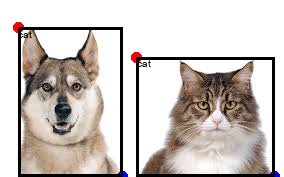

In [68]:
for box in data:
    x1, y1, x2, y2, conf, predict = box
    #print(names[int(predict)])
    #왼쪽ㅇ위 좌표 점으로 표시하기
    draw.ellipse([x1-r,y1-r,x1+r,y1+r],fill="red")

    # 오른쪽 좌표 저믕로 표시하기
    draw.ellipse([x2-r,y2-r,x2+r,y2+r],fill="blue")
    #box = result.boxes

    # 박스 그리기
    draw.rectangle([x1,y1,x2,y2],outline="black",width=3)

    #라벨출력
    draw.text((x1,y1),text=names[int(predict)],fill="black",font=font)
img